In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import os

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define the base results directory
results_base_dir = "/data/projects/punim0478/setiawand/bible-nmt/results"

# Function to automatically load all filtered metrics JSON files
def load_gemini_results(base_dir):
    results_data = {}
    
    # Find all gemini-2.5-flash-*-dhao directories
    gemini_dirs = glob.glob(os.path.join(base_dir, "gemini-2.5-flash-*-dhao"))
    
    for gemini_dir in sorted(gemini_dirs):
        # Extract variant name from directory (e.g., "engBBE" from "gemini-2.5-flash-engBBE-dhao")
        dir_name = os.path.basename(gemini_dir)
        variant = dir_name.replace("gemini-2.5-flash-", "").replace("-dhao", "")
        
        print(f"Processing variant: {variant}")
        
        # Find all parallel_* subdirectories
        parallel_dirs = glob.glob(os.path.join(gemini_dir, "parallel_*"))
        
        for parallel_dir in sorted(parallel_dirs):
            training_config = os.path.basename(parallel_dir)
            
            # Look for the filtered metrics JSON file
            json_pattern = os.path.join(parallel_dir, "*-filtered_metrics.json")
            json_files = glob.glob(json_pattern)
            
            if json_files:
                json_file = json_files[0]  # Take the first match
                print(f"  Loading: {training_config} -> {os.path.basename(json_file)}")
                
                try:
                    with open(json_file, 'r') as f:
                        data = json.load(f)
                    
                    # Create key for this configuration
                    config_key = f"{variant}-{training_config}"
                    results_data[config_key] = data
                    
                except Exception as e:
                    print(f"    Error loading {json_file}: {e}")
            else:
                print(f"    No filtered metrics JSON found in {parallel_dir}")
    
    return results_data

# Load all the data automatically
print("🔍 Automatically discovering and loading JSON files...")
print("=" * 60)

results_data = load_gemini_results(results_base_dir)

print("=" * 60)
print("✅ Data loaded successfully!")
print(f"📊 Total configurations analyzed: {len(results_data)}")

if results_data:
    variants = list(set([key.split('-')[0] for key in results_data.keys()]))
    training_configs = list(set([key.split('-', 1)[1] for key in results_data.keys()]))
    
    print(f"🧬 Variants found: {variants}")
    print(f"⚙️  Training configs: {training_configs}")
    
    # Show a sample of the loaded data
    print(f"\n📋 Sample configuration: {list(results_data.keys())[0]}")
    sample_data = results_data[list(results_data.keys())[0]]
    print(f"   Metrics available: {list(sample_data.keys())}")
else:
    print("❌ No data found! Please check the directory structure.")


🔍 Automatically discovering and loading JSON files...
Processing variant: engBBE
  Loading: parallel_full -> gemini-2.5-flash_aligned-eng-engBBE-ot_eng_nfa-filtered_metrics.json
  Loading: parallel_full+nt -> gemini-2.5-flash_aligned-eng-engBBE-ot_eng_nfa-filtered_metrics.json
  Loading: parallel_nt -> gemini-2.5-flash_aligned-eng-engBBE-ot_eng_nfa-filtered_metrics.json
Processing variant: engwyc2017
  Loading: parallel_full -> gemini-2.5-flash_aligned-eng-engwyc2017-ot_eng_nfa-filtered_metrics.json
  Loading: parallel_full+nt -> gemini-2.5-flash_aligned-eng-engwyc2017-ot_eng_nfa-filtered_metrics.json
  Loading: parallel_nt -> gemini-2.5-flash_aligned-eng-engwyc2017-ot_eng_nfa-filtered_metrics.json
Processing variant: engwyc2018
  Loading: parallel_full -> gemini-2.5-flash_aligned-eng-engwyc2018-ot_eng_nfa-filtered_metrics.json
  Loading: parallel_full+nt -> gemini-2.5-flash_aligned-eng-engwyc2018-ot_eng_nfa-filtered_metrics.json
  Loading: parallel_nt -> gemini-2.5-flash_aligned-eng-e

In [2]:
# Convert data to DataFrame for easier analysis
df_rows = []
for config_name, metrics in results_data.items():
    variant, training_config = config_name.split('-', 1)
    
    # Add original metrics
    row_orig = {'variant': variant, 'training_config': training_config, 'metric_type': 'original'}
    row_orig.update(metrics['original_mt_metrics'])
    df_rows.append(row_orig)
    
    # Add post-edited metrics  
    row_pe = {'variant': variant, 'training_config': training_config, 'metric_type': 'post_edited'}
    row_pe.update(metrics['post_edited_metrics'])
    df_rows.append(row_pe)
    
    # Add improvement metrics
    row_imp = {'variant': variant, 'training_config': training_config, 'metric_type': 'improvement'}
    row_imp.update(metrics['improvements'])
    df_rows.append(row_imp)

df = pd.DataFrame(df_rows)

# Create separate DataFrames for different analyses
df_post_edited = df[df['metric_type'] == 'post_edited'].copy()
df_improvements = df[df['metric_type'] == 'improvement'].copy()

print("DataFrame shapes:")
print(f"Full data: {df.shape}")
print(f"Post-edited only: {df_post_edited.shape}")
print(f"Improvements only: {df_improvements.shape}")
print("\nAvailable variants:", df['variant'].unique())
print("Training configurations:", df['training_config'].unique())


DataFrame shapes:
Full data: (36, 9)
Post-edited only: (12, 9)
Improvements only: (12, 9)

Available variants: ['engBBE' 'engwyc2017' 'engwyc2018' 'webp']
Training configurations: ['parallel_full' 'parallel_full+nt' 'parallel_nt']


In [3]:
# REVAMPED ANALYSIS: First find best training config for each version, then compare
print("=" * 80)
print("STEP 1: FIND BEST TRAINING CONFIGURATION FOR EACH BIBLE VERSION")
print("=" * 80)

# Focus on the requested metrics only
metrics_to_analyze = ['sacrebleu', 'spbleu', 'chrf3', 'chrf++']
print(f"📊 Analyzing metrics: {metrics_to_analyze}")

print("\n🔍 Finding best training configuration for each Bible version...")
print("-" * 60)

best_configs_by_version = {}

for variant in df_improvements['variant'].unique():
    print(f"\n📖 {variant.upper()}:")
    
    variant_data = df_improvements[df_improvements['variant'] == variant]
    
    # Calculate average improvement across the 3 metrics for each training config
    config_scores = {}
    for training_config in variant_data['training_config'].unique():
        config_data = variant_data[variant_data['training_config'] == training_config]
        avg_improvement = config_data[metrics_to_analyze].mean().mean()
        config_scores[training_config] = avg_improvement
        
        print(f"  {training_config:15}: {avg_improvement:7.4f} (avg improvement)")
    
    # Find the best training config for this variant
    best_config = max(config_scores.items(), key=lambda x: x[1])
    best_configs_by_version[variant] = {
        'training_config': best_config[0],
        'avg_improvement': best_config[1]
    }
    
    print(f"  🏆 WINNER: {best_config[0]} ({best_config[1]:.4f})")

print("\n" + "=" * 80)
print("STEP 2: COMPARE BEST CONFIGURATIONS ACROSS BIBLE VERSIONS")
print("=" * 80)

# Create a filtered dataset with only the best configurations
best_config_data = []

for variant in best_configs_by_version.keys():
    best_training_config = best_configs_by_version[variant]['training_config']
    
    # Get the data for this best configuration
    config_key = f"{variant}-{best_training_config}"
    if config_key in results_data:
        best_config_data.append({
            'variant': variant,
            'training_config': best_training_config,
            'config_key': config_key,
            'data': results_data[config_key]
        })

print(f"\n📊 Comparing {len(best_config_data)} best configurations:")
for config in best_config_data:
    print(f"  • {config['variant'].upper()}: {config['training_config']}")

# Create comparison DataFrames with only the best configurations
best_pe_comparison = []
best_imp_comparison = []

for config in best_config_data:
    variant = config['variant']
    training_config = config['training_config']
    data = config['data']
    
    # Post-edited metrics
    pe_row = {'variant': variant, 'training_config': training_config}
    pe_row.update(data['post_edited_metrics'])
    best_pe_comparison.append(pe_row)
    
    # Improvement metrics  
    imp_row = {'variant': variant, 'training_config': training_config}
    imp_row.update(data['improvements'])
    best_imp_comparison.append(imp_row)

best_pe_df = pd.DataFrame(best_pe_comparison)
best_imp_df = pd.DataFrame(best_imp_comparison)

print("\n1. POST-EDITED PERFORMANCE (Best configs only):")
print("-" * 50)

for _, row in best_pe_df.iterrows():
    print(f"\n{row['variant'].upper()} ({row['training_config']}):")
    for metric in metrics_to_analyze:
        print(f"  {metric:10}: {row[metric]:7.4f}")

print("\n2. IMPROVEMENTS (Best configs only):")
print("-" * 40)

for _, row in best_imp_df.iterrows():
    print(f"\n{row['variant'].upper()} ({row['training_config']}):")
    for metric in metrics_to_analyze:
        print(f"  {metric:10}: +{row[metric]:6.4f}")

# Rank the best configurations
print("\n3. FINAL RANKING (Best config from each version):")
print("-" * 55)

# Rank by post-edited performance
pe_rankings = {}
for metric in metrics_to_analyze:
    ranked = best_pe_df.sort_values(metric, ascending=False)
    for i, (_, row) in enumerate(ranked.iterrows()):
        variant = row['variant']
        if variant not in pe_rankings:
            pe_rankings[variant] = []
        pe_rankings[variant].append(i + 1)

avg_pe_rankings = {variant: np.mean(ranks) for variant, ranks in pe_rankings.items()}
sorted_pe_rankings = sorted(avg_pe_rankings.items(), key=lambda x: x[1])

print("\nA. BY POST-EDITED PERFORMANCE:")
for i, (variant, avg_rank) in enumerate(sorted_pe_rankings):
    config = best_configs_by_version[variant]['training_config']
    print(f"  {i+1}. {variant.upper():12} ({config:15}) - Avg rank: {avg_rank:.2f}")

# Rank by improvement
imp_rankings = {}
for metric in metrics_to_analyze:
    ranked = best_imp_df.sort_values(metric, ascending=False)
    for i, (_, row) in enumerate(ranked.iterrows()):
        variant = row['variant']
        if variant not in imp_rankings:
            imp_rankings[variant] = []
        imp_rankings[variant].append(i + 1)

avg_imp_rankings = {variant: np.mean(ranks) for variant, ranks in imp_rankings.items()}
sorted_imp_rankings = sorted(avg_imp_rankings.items(), key=lambda x: x[1])

print("\nB. BY IMPROVEMENT:")
for i, (variant, avg_rank) in enumerate(sorted_imp_rankings):
    config = best_configs_by_version[variant]['training_config']
    print(f"  {i+1}. {variant.upper():12} ({config:15}) - Avg rank: {avg_rank:.2f}")

print(f"\n🏆 OVERALL WINNER (Performance): {sorted_pe_rankings[0][0].upper()}")
print(f"🚀 BEST IMPROVER: {sorted_imp_rankings[0][0].upper()}")


STEP 1: FIND BEST TRAINING CONFIGURATION FOR EACH BIBLE VERSION
📊 Analyzing metrics: ['sacrebleu', 'spbleu', 'chrf3', 'chrf++']

🔍 Finding best training configuration for each Bible version...
------------------------------------------------------------

📖 ENGBBE:
  parallel_full  :  4.1872 (avg improvement)
  parallel_full+nt:  7.6414 (avg improvement)
  parallel_nt    :  6.9311 (avg improvement)
  🏆 WINNER: parallel_full+nt (7.6414)

📖 ENGWYC2017:
  parallel_full  :  4.3390 (avg improvement)
  parallel_full+nt:  8.0884 (avg improvement)
  parallel_nt    :  8.0033 (avg improvement)
  🏆 WINNER: parallel_full+nt (8.0884)

📖 ENGWYC2018:
  parallel_full  :  4.3936 (avg improvement)
  parallel_full+nt:  8.0763 (avg improvement)
  parallel_nt    :  8.0657 (avg improvement)
  🏆 WINNER: parallel_full+nt (8.0763)

📖 WEBP:
  parallel_full  :  3.8914 (avg improvement)
  parallel_full+nt:  7.6143 (avg improvement)
  parallel_nt    :  7.3276 (avg improvement)
  🏆 WINNER: parallel_full+nt (7.6143)



STEP 4: VISUALIZATIONS (Best Configurations Only)


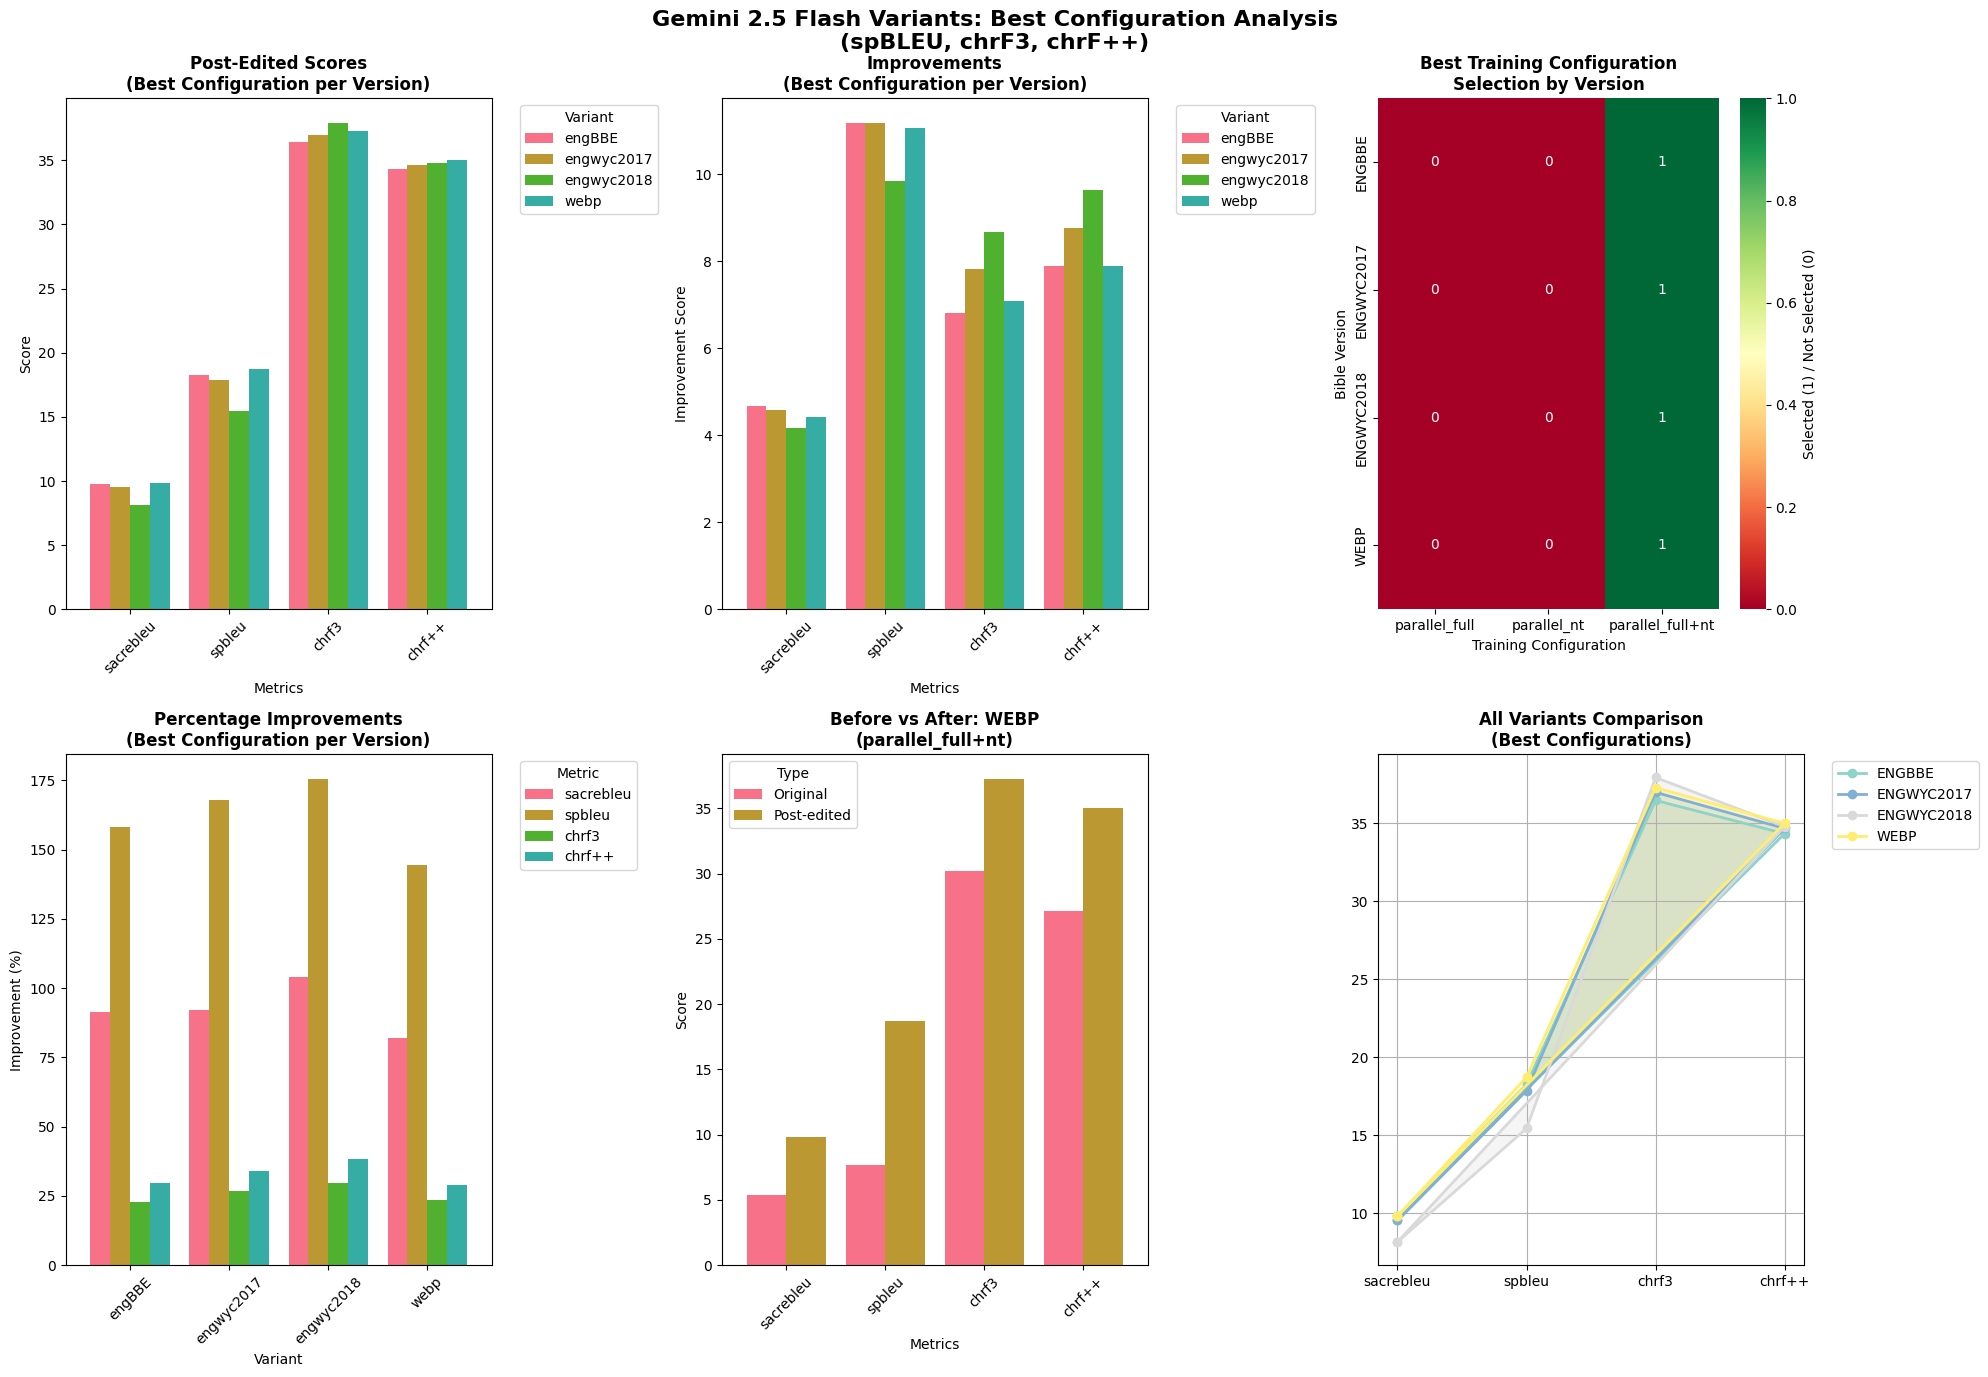

✅ Visualizations created successfully!

📊 Key Insights from Visualizations:
   • Chart 1-2: Direct performance comparison of best configs
   • Chart 3: Shows which training configs work best for each version
   • Chart 4: Percentage improvements highlight relative gains
   • Chart 5: Before/after for the overall winner
   • Chart 6: Radar plot shows strengths across all metrics


In [4]:
# Create comprehensive visualizations for BEST CONFIGURATIONS ONLY
print("\n" + "=" * 80)
print("STEP 4: VISUALIZATIONS (Best Configurations Only)")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('Gemini 2.5 Flash Variants: Best Configuration Analysis\n(spBLEU, chrF3, chrF++)', fontsize=16, fontweight='bold')

# 1. Post-edited scores (best configs only)
ax1 = axes[0, 0]
best_pe_plot_data = best_pe_df.set_index('variant')[metrics_to_analyze].T
best_pe_plot_data.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Post-Edited Scores\n(Best Configuration per Version)', fontweight='bold')
ax1.set_xlabel('Metrics')
ax1.set_ylabel('Score')
ax1.legend(title='Variant', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# 2. Improvements (best configs only)
ax2 = axes[0, 1]
best_imp_plot_data = best_imp_df.set_index('variant')[metrics_to_analyze].T
best_imp_plot_data.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Improvements\n(Best Configuration per Version)', fontweight='bold')
ax2.set_xlabel('Metrics')
ax2.set_ylabel('Improvement Score')
ax2.legend(title='Variant', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=45)

# 3. Training configuration selection heatmap
ax3 = axes[0, 2]
config_matrix = []
variants_ordered = sorted(best_configs_by_version.keys())
all_configs = ['parallel_full', 'parallel_nt', 'parallel_full+nt']

for variant in variants_ordered:
    best_config = best_configs_by_version[variant]['training_config']
    row = [1 if config == best_config else 0 for config in all_configs]
    config_matrix.append(row)

config_df = pd.DataFrame(config_matrix, index=[v.upper() for v in variants_ordered], columns=all_configs)
sns.heatmap(config_df, annot=True, fmt='d', cmap='RdYlGn', ax=ax3, cbar_kws={'label': 'Selected (1) / Not Selected (0)'})
ax3.set_title('Best Training Configuration\nSelection by Version', fontweight='bold')
ax3.set_xlabel('Training Configuration')
ax3.set_ylabel('Bible Version')

# 4. Percentage improvements (best configs only)
ax4 = axes[1, 0]
pct_improvements_best = {}
for config in best_config_data:
    variant = config['variant']
    data = config['data']
    
    pct_improvements_best[variant] = {}
    for metric in metrics_to_analyze:
        orig = data['original_mt_metrics'][metric]
        imp = data['improvements'][metric]
        pct_improvements_best[variant][metric] = (imp / orig) * 100 if orig > 0 else 0

pct_imp_best_df = pd.DataFrame(pct_improvements_best).T
pct_imp_best_df.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_title('Percentage Improvements\n(Best Configuration per Version)', fontweight='bold')
ax4.set_xlabel('Variant')
ax4.set_ylabel('Improvement (%)')
ax4.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.tick_params(axis='x', rotation=45)

# 5. Before vs After comparison for overall winner
ax5 = axes[1, 1]
winner_variant = sorted_pe_rankings[0][0]
winner_config = best_configs_by_version[winner_variant]['training_config']
winner_data = None

for config in best_config_data:
    if config['variant'] == winner_variant:
        winner_data = config['data']
        break

if winner_data:
    comparison_data = pd.DataFrame({
        'Original': [winner_data['original_mt_metrics'][m] for m in metrics_to_analyze],
        'Post-edited': [winner_data['post_edited_metrics'][m] for m in metrics_to_analyze]
    }, index=metrics_to_analyze)
    
    comparison_data.plot(kind='bar', ax=ax5, width=0.8)
    ax5.set_title(f'Before vs After: {winner_variant.upper()}\n({winner_config})', fontweight='bold')
    ax5.set_xlabel('Metrics')
    ax5.set_ylabel('Score')
    ax5.legend(title='Type')
    ax5.tick_params(axis='x', rotation=45)

# 6. Radar plot for all variants (best configs)
ax6 = axes[1, 2]
angles = np.linspace(0, 2 * np.pi, len(metrics_to_analyze), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))  # Complete the circle

colors = plt.cm.Set3(np.linspace(0, 1, len(best_config_data)))

for i, config in enumerate(best_config_data):
    variant = config['variant']
    data = config['data']
    
    values = [data['post_edited_metrics'][m] for m in metrics_to_analyze]
    values += [values[0]]  # Complete the circle
    
    ax6.plot(angles, values, 'o-', linewidth=2, label=f"{variant.upper()}", color=colors[i])
    ax6.fill(angles, values, alpha=0.25, color=colors[i])

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(metrics_to_analyze)
ax6.set_title('All Variants Comparison\n(Best Configurations)', fontweight='bold')
ax6.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax6.grid(True)

plt.tight_layout()
plt.show()

print("✅ Visualizations created successfully!")
print("\n📊 Key Insights from Visualizations:")
print("   • Chart 1-2: Direct performance comparison of best configs")
print("   • Chart 3: Shows which training configs work best for each version")
print("   • Chart 4: Percentage improvements highlight relative gains") 
print("   • Chart 5: Before/after for the overall winner")
print("   • Chart 6: Radar plot shows strengths across all metrics")


In [5]:
# Final Summary and Recommendations
print("\n" + "=" * 80)
print("STEP 5: FINAL SUMMARY & RECOMMENDATIONS")
print("=" * 80)

print("\n🎯 EXECUTIVE SUMMARY:")
print("-" * 30)

# Best overall performer
best_overall = sorted_pe_rankings[0][0]
best_overall_rank = sorted_pe_rankings[0][1]
best_overall_config = best_configs_by_version[best_overall]['training_config']

print(f"🏆 BEST OVERALL PERFORMANCE: {best_overall.upper()}")
print(f"   Best configuration: {best_overall_config}")
print(f"   Average rank across metrics: {best_overall_rank:.2f}")

# Best improvement performer  
best_improvement = sorted_imp_rankings[0][0]
best_improvement_rank = sorted_imp_rankings[0][1]
best_improvement_config = best_configs_by_version[best_improvement]['training_config']

print(f"🚀 HIGHEST IMPROVEMENT: {best_improvement.upper()}")
print(f"   Best configuration: {best_improvement_config}")
print(f"   Average rank across metrics: {best_improvement_rank:.2f}")

# Check if they're the same
if best_overall == best_improvement:
    print(f"\n✅ CLEAR WINNER: {best_overall.upper()} excels in BOTH categories!")
    print(f"   Recommended setup: {best_overall.upper()} with {best_overall_config}")
else:
    print(f"\n📝 Different variants excel in different aspects:")
    print(f"   Choose based on your priority (performance vs improvement)")

print(f"\n📚 TRAINING CONFIGURATION ANALYSIS:")
print("-" * 45)

# Show what we learned about training configs
print("Best training configuration for each Bible version:")
for variant, info in best_configs_by_version.items():
    config = info['training_config']
    improvement = info['avg_improvement']
    print(f"  {variant.upper():12}: {config:15} (avg improv: +{improvement:.4f})")

# Training config patterns
config_counts = {}
for variant, info in best_configs_by_version.items():
    config = info['training_config']
    config_counts[config] = config_counts.get(config, 0) + 1

print(f"\nTraining configuration success rate:")
for config, count in sorted(config_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / len(best_configs_by_version)) * 100
    print(f"  {config:15}: {count}/{len(best_configs_by_version)} versions ({percentage:5.1f}%)")

if len(set(config_counts.keys())) == 1:
    winning_config = list(config_counts.keys())[0]
    print(f"\n✅ UNANIMOUS WINNER: {winning_config}")
    print("   All Bible versions perform best with this configuration!")
else:
    most_common = max(config_counts.items(), key=lambda x: x[1])
    print(f"\n🏆 MOST SUCCESSFUL CONFIG: {most_common[0]} ({most_common[1]} versions)")

print(f"\n💡 KEY RECOMMENDATIONS:")
print("-" * 35)

print("1. BIBLE VERSION SELECTION:")
if best_overall == best_improvement:
    print(f"   → Use {best_overall.upper()} - best in both performance and improvement")
else:
    print(f"   → For max performance: {best_overall.upper()}")
    print(f"   → For max improvement: {best_improvement.upper()}")

print(f"\n2. TRAINING CONFIGURATION:")
if len(set(config_counts.keys())) == 1:
    print(f"   → Always use {list(config_counts.keys())[0]}")
else:
    most_common = max(config_counts.items(), key=lambda x: x[1])
    print(f"   → Generally use {most_common[0]} (works best for {most_common[1]}/{len(best_configs_by_version)} versions)")
    print(f"   → But check specific version recommendations above")

print(f"\n3. EXPECTED IMPROVEMENTS:")
winner_data = None
for config in best_config_data:
    if config['variant'] == best_overall:
        winner_data = config['data']
        break

if winner_data:
    print(f"   Using {best_overall.upper()} with {best_overall_config}:")
    for metric in metrics_to_analyze:
        orig = winner_data['original_mt_metrics'][metric]
        improved = winner_data['post_edited_metrics'][metric]  
        improvement = winner_data['improvements'][metric]
        pct = (improvement / orig) * 100
        print(f"     {metric:8}: {orig:6.2f} → {improved:6.2f} (+{improvement:5.2f}, {pct:5.1f}%)")

print(f"\n🔍 METHODOLOGY VALIDATION:")
print("-" * 35)
print("✅ This analysis used a 2-step approach:")
print("   1. Found the best training config for each Bible version")
print("   2. Compared only the best configurations against each other")
print("   This ensures fair comparison of each version's peak performance")

total_configs = len(results_data)
best_configs_used = len(best_config_data)
print(f"\n📊 Analysis scope: {best_configs_used}/{total_configs} configurations (best from each version)")
print(f"📈 Metrics analyzed: {', '.join(metrics_to_analyze)}")

print("\n" + "=" * 80)
print("🎉 ANALYSIS COMPLETE!")
print("Use the recommendations above to select your optimal Bible NMT setup.")
print("=" * 80)



STEP 5: FINAL SUMMARY & RECOMMENDATIONS

🎯 EXECUTIVE SUMMARY:
------------------------------
🏆 BEST OVERALL PERFORMANCE: WEBP
   Best configuration: parallel_full+nt
   Average rank across metrics: 1.25
🚀 HIGHEST IMPROVEMENT: ENGWYC2017
   Best configuration: parallel_full+nt
   Average rank across metrics: 1.75

📝 Different variants excel in different aspects:
   Choose based on your priority (performance vs improvement)

📚 TRAINING CONFIGURATION ANALYSIS:
---------------------------------------------
Best training configuration for each Bible version:
  ENGBBE      : parallel_full+nt (avg improv: +7.6414)
  ENGWYC2017  : parallel_full+nt (avg improv: +8.0884)
  ENGWYC2018  : parallel_full+nt (avg improv: +8.0763)
  WEBP        : parallel_full+nt (avg improv: +7.6143)

Training configuration success rate:
  parallel_full+nt: 4/4 versions (100.0%)

✅ UNANIMOUS WINNER: parallel_full+nt
   All Bible versions perform best with this configuration!

💡 KEY RECOMMENDATIONS:
-----------------

In [6]:
# CORRELATION ANALYSIS: Improvement Score vs Perplexity
print("\n" + "=" * 80)
print("STEP 6: CORRELATION WITH PERPLEXITY SCORES")
print("=" * 80)

# Load perplexity scores
perplexity_file = "/data/projects/punim0478/setiawand/bible-nmt/perplexity_scoring/bible_perplexity_scores_filtered.csv"
perplexity_df = pd.read_csv(perplexity_file)

print(f"\n📊 Loaded perplexity scores from: {perplexity_file}")
print(f"   Total rows: {len(perplexity_df)}")

# Map variant names to perplexity scores
# Note: 'webp' in our data should map to 'engwebp' in perplexity data
variant_mapping = {
    'engBBE': 'engBBE',
    'engwyc2017': 'engwyc2017', 
    'engwyc2018': 'engwyc2018',
    'webp': 'engwebp'
}

print(f"\n🔍 Filtering perplexity scores for our variants:")
print("-" * 60)

# Filter perplexity data for our variants
filtered_perplexity = []
for our_variant, perplexity_variant in variant_mapping.items():
    match = perplexity_df[perplexity_df['english_version'] == perplexity_variant]
    if len(match) > 0:
        perplexity_score = match.iloc[0]['perplexity_score']
        filtered_perplexity.append({
            'variant': our_variant,
            'perplexity_score': perplexity_score
        })
        print(f"  ✅ {our_variant:12} ({perplexity_variant:12}) → Perplexity: {perplexity_score:.2f}")
    else:
        print(f"  ❌ {our_variant:12} ({perplexity_variant:12}) → NOT FOUND in perplexity data")

perplexity_filtered_df = pd.DataFrame(filtered_perplexity)

# Merge with our best improvement data
correlation_df = best_imp_df.merge(perplexity_filtered_df, on='variant', how='inner')

print(f"\n📋 Combined data for correlation analysis:")
print(correlation_df[['variant', 'training_config', 'spbleu', 'chrf3', 'chrf++', 'perplexity_score']])

# Calculate correlations
print(f"\n📈 CORRELATION ANALYSIS:")
print("-" * 60)
print("Correlation between perplexity score and improvement metrics:\n")

for metric in metrics_to_analyze:
    corr = correlation_df['perplexity_score'].corr(correlation_df[metric])
    print(f"  {metric:10}: {corr:7.4f}")
    
    # Interpret the correlation
    if abs(corr) < 0.3:
        strength = "weak"
    elif abs(corr) < 0.7:
        strength = "moderate"
    else:
        strength = "strong"
    
    direction = "positive" if corr > 0 else "negative"
    print(f"             ({strength} {direction} correlation)")
    
    if corr > 0:
        print(f"             → Higher perplexity → Higher improvement")
    else:
        print(f"             → Higher perplexity → Lower improvement")
    print()

# Calculate average improvement correlation
avg_improvement = correlation_df[metrics_to_analyze].mean(axis=1)
correlation_df['avg_improvement'] = avg_improvement
corr_avg = correlation_df['perplexity_score'].corr(correlation_df['avg_improvement'])

print(f"  {'Avg Improv':10}: {corr_avg:7.4f}")
if abs(corr_avg) < 0.3:
    strength = "weak"
elif abs(corr_avg) < 0.7:
    strength = "moderate"
else:
    strength = "strong"
direction = "positive" if corr_avg > 0 else "negative"
print(f"             ({strength} {direction} correlation)")
print(f"             → This is the overall trend across all metrics")

# Statistical significance (basic interpretation)
print(f"\n💡 INTERPRETATION:")
print("-" * 60)

if corr_avg > 0.5:
    print("✅ POSITIVE CORRELATION: Higher perplexity scores are associated with")
    print("   higher improvement scores. This suggests that Bible versions that")
    print("   are more 'different' or complex compared to the target language")
    print("   benefit more from post-editing.")
elif corr_avg < -0.5:
    print("✅ NEGATIVE CORRELATION: Lower perplexity scores are associated with")
    print("   higher improvement scores. This suggests that Bible versions that")
    print("   are more 'similar' to the target language benefit more from")
    print("   post-editing.")
else:
    print("⚠️  WEAK/NO CORRELATION: Perplexity score does not show a strong")
    print("   relationship with improvement scores. This suggests that other")
    print("   factors (e.g., translation style, vocabulary) may be more")
    print("   important for post-editing improvement than perplexity alone.")

print(f"\n⚠️  NOTE: With only {len(correlation_df)} data points, statistical")
print("   significance is limited. More Bible versions would be needed for")
print("   stronger conclusions.")

print("\n" + "=" * 80)



STEP 6: CORRELATION WITH PERPLEXITY SCORES

📊 Loaded perplexity scores from: /data/projects/punim0478/setiawand/bible-nmt/perplexity_scoring/bible_perplexity_scores_filtered.csv
   Total rows: 30

🔍 Filtering perplexity scores for our variants:
------------------------------------------------------------
  ✅ engBBE       (engBBE      ) → Perplexity: 97.34
  ✅ engwyc2017   (engwyc2017  ) → Perplexity: 100.77
  ✅ engwyc2018   (engwyc2018  ) → Perplexity: 189.31
  ✅ webp         (engwebp     ) → Perplexity: 109.32

📋 Combined data for correlation analysis:
      variant   training_config   spbleu   chrf3  chrf++  perplexity_score
0      engBBE  parallel_full+nt  11.1883  6.8125  7.8876           97.3408
1  engwyc2017  parallel_full+nt  11.1889  7.8202  8.7711          100.7690
2  engwyc2018  parallel_full+nt   9.8379  8.6704  9.6320          189.3110
3        webp  parallel_full+nt  11.0642  7.0858  7.8860          109.3180

📈 CORRELATION ANALYSIS:
---------------------------------------


STEP 7: CORRELATION VISUALIZATION


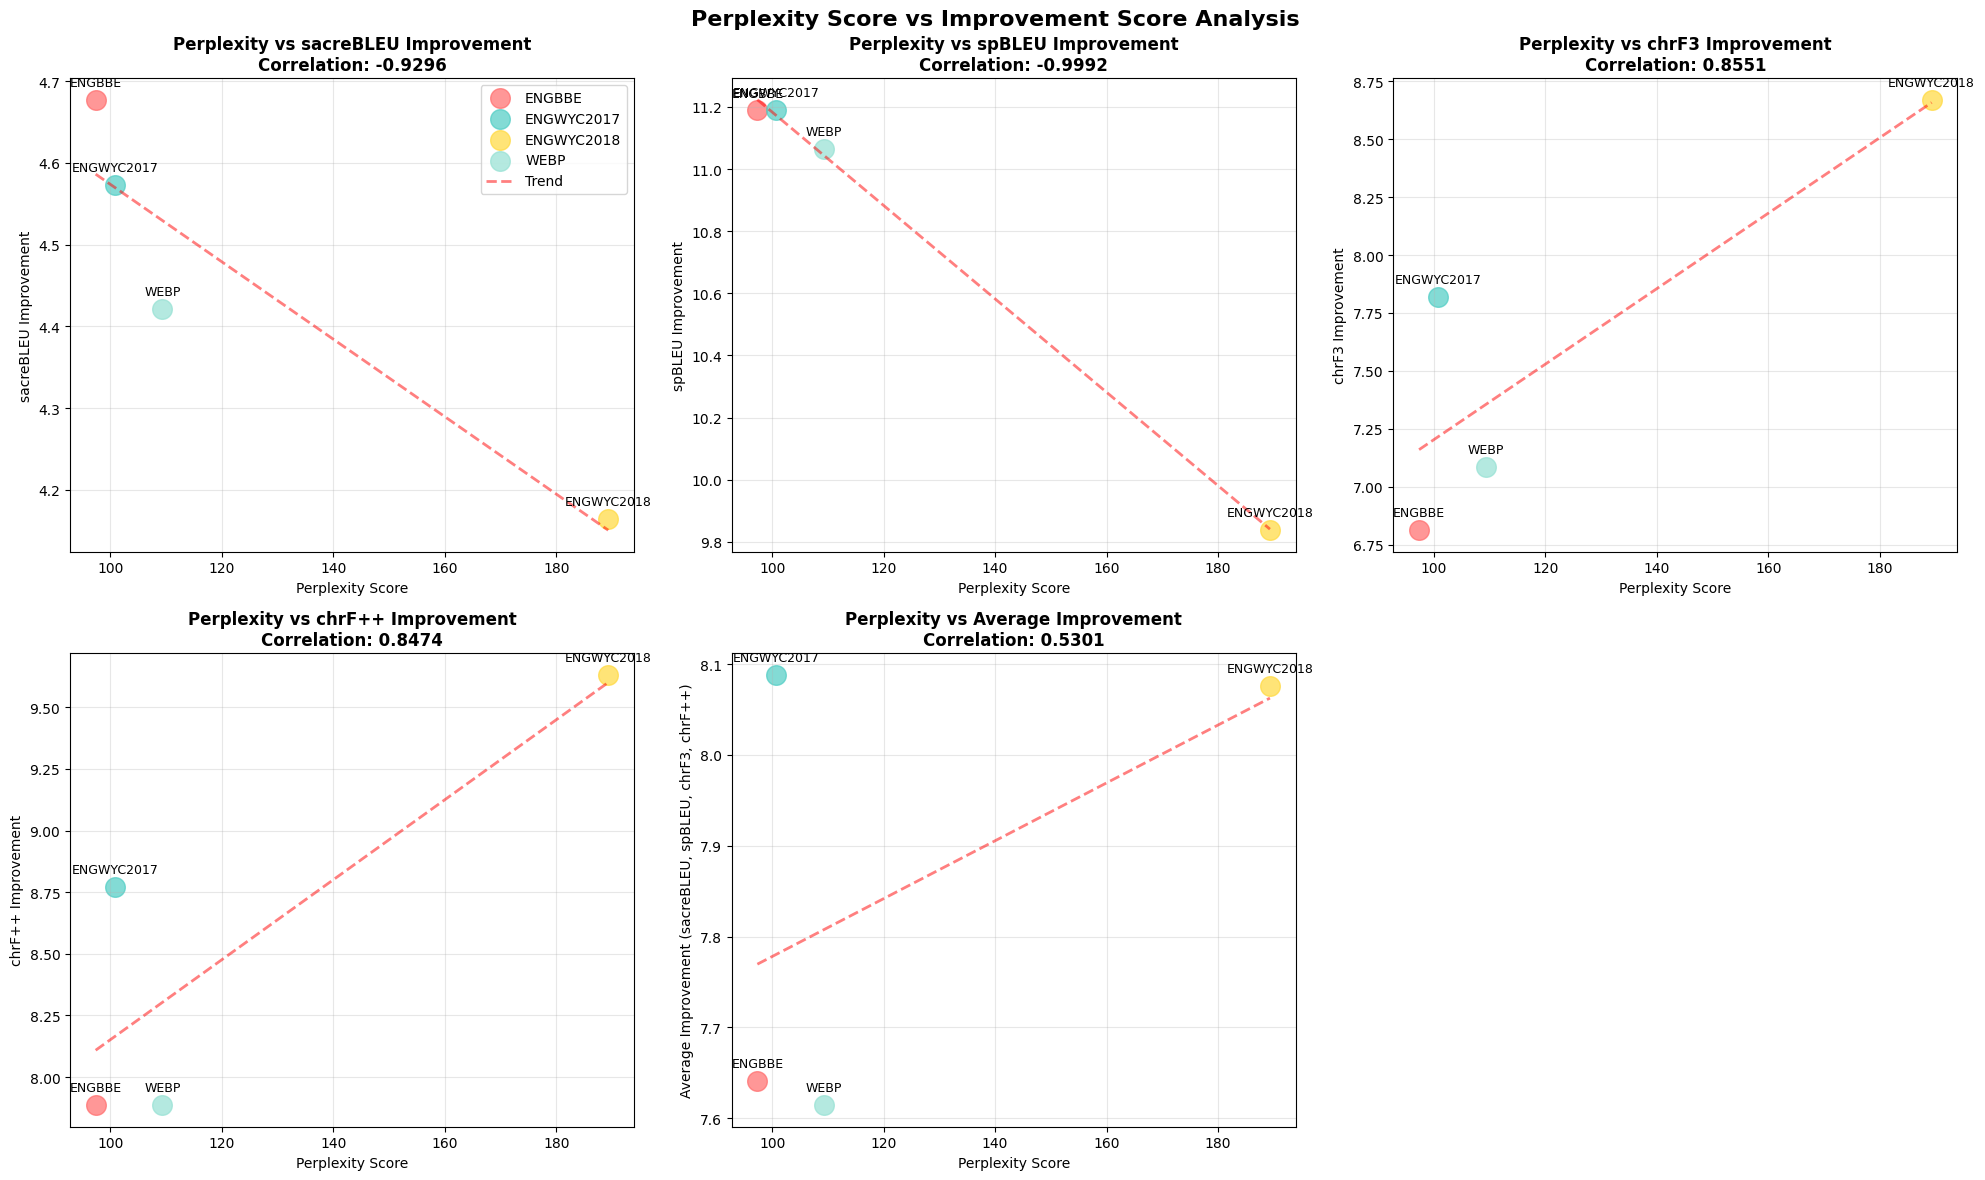

✅ Correlation visualizations created successfully!

📊 Visual Interpretation:
   • Red dashed lines show the trend
   • Upward slope = positive correlation (higher perplexity → higher improvement)
   • Downward slope = negative correlation (higher perplexity → lower improvement)
   • Flat line = no correlation



In [7]:
# VISUALIZATION: Perplexity vs Improvement Correlation
print("\n" + "=" * 80)
print("STEP 7: CORRELATION VISUALIZATION")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Perplexity Score vs Improvement Score Analysis', fontsize=16, fontweight='bold')

# Create color map for variants
colors_map = {'engBBE': '#FF6B6B', 'engwyc2017': '#4ECDC4', 'engwyc2018': '#FFD93D', 'webp': '#95E1D3'}

# 1. Scatter plot: Perplexity vs sacrebleu improvement
ax1 = axes[0, 0]
for _, row in correlation_df.iterrows():
    ax1.scatter(row['perplexity_score'], row['sacrebleu'], 
                s=200, alpha=0.7, c=colors_map.get(row['variant'], 'gray'),
                label=row['variant'].upper())
    ax1.annotate(row['variant'].upper(), 
                (row['perplexity_score'], row['sacrebleu']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Add trendline
z = np.polyfit(correlation_df['perplexity_score'], correlation_df['sacrebleu'], 1)
p = np.poly1d(z)
x_line = np.linspace(correlation_df['perplexity_score'].min(), correlation_df['perplexity_score'].max(), 100)
ax1.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2, label='Trend')

corr1 = correlation_df['perplexity_score'].corr(correlation_df['sacrebleu'])
ax1.set_title(f'Perplexity vs sacreBLEU Improvement\nCorrelation: {corr1:.4f}', fontweight='bold')
ax1.set_xlabel('Perplexity Score')
ax1.set_ylabel('sacreBLEU Improvement')
ax1.grid(True, alpha=0.3)
# Remove duplicate labels
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='best')

# 2. Scatter plot: Perplexity vs spBLEU improvement
ax2 = axes[0, 1]
for _, row in correlation_df.iterrows():
    ax2.scatter(row['perplexity_score'], row['spbleu'], 
                s=200, alpha=0.7, c=colors_map.get(row['variant'], 'gray'))
    ax2.annotate(row['variant'].upper(), 
                (row['perplexity_score'], row['spbleu']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Add trendline
z = np.polyfit(correlation_df['perplexity_score'], correlation_df['spbleu'], 1)
p = np.poly1d(z)
ax2.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)

corr2 = correlation_df['perplexity_score'].corr(correlation_df['spbleu'])
ax2.set_title(f'Perplexity vs spBLEU Improvement\nCorrelation: {corr2:.4f}', fontweight='bold')
ax2.set_xlabel('Perplexity Score')
ax2.set_ylabel('spBLEU Improvement')
ax2.grid(True, alpha=0.3)

# 3. Scatter plot: Perplexity vs chrF3 improvement
ax3 = axes[0, 2]
for _, row in correlation_df.iterrows():
    ax3.scatter(row['perplexity_score'], row['chrf3'], 
                s=200, alpha=0.7, c=colors_map.get(row['variant'], 'gray'))
    ax3.annotate(row['variant'].upper(), 
                (row['perplexity_score'], row['chrf3']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Add trendline
z = np.polyfit(correlation_df['perplexity_score'], correlation_df['chrf3'], 1)
p = np.poly1d(z)
ax3.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)

corr3 = correlation_df['perplexity_score'].corr(correlation_df['chrf3'])
ax3.set_title(f'Perplexity vs chrF3 Improvement\nCorrelation: {corr3:.4f}', fontweight='bold')
ax3.set_xlabel('Perplexity Score')
ax3.set_ylabel('chrF3 Improvement')
ax3.grid(True, alpha=0.3)

# 4. Scatter plot: Perplexity vs chrF++ improvement
ax4 = axes[1, 0]
for _, row in correlation_df.iterrows():
    ax4.scatter(row['perplexity_score'], row['chrf++'], 
                s=200, alpha=0.7, c=colors_map.get(row['variant'], 'gray'))
    ax4.annotate(row['variant'].upper(), 
                (row['perplexity_score'], row['chrf++']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Add trendline
z = np.polyfit(correlation_df['perplexity_score'], correlation_df['chrf++'], 1)
p = np.poly1d(z)
ax4.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)

corr4 = correlation_df['perplexity_score'].corr(correlation_df['chrf++'])
ax4.set_title(f'Perplexity vs chrF++ Improvement\nCorrelation: {corr4:.4f}', fontweight='bold')
ax4.set_xlabel('Perplexity Score')
ax4.set_ylabel('chrF++ Improvement')
ax4.grid(True, alpha=0.3)

# 5. Scatter plot: Perplexity vs Average improvement
ax5 = axes[1, 1]
for _, row in correlation_df.iterrows():
    ax5.scatter(row['perplexity_score'], row['avg_improvement'], 
                s=200, alpha=0.7, c=colors_map.get(row['variant'], 'gray'))
    ax5.annotate(row['variant'].upper(), 
                (row['perplexity_score'], row['avg_improvement']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Add trendline
z = np.polyfit(correlation_df['perplexity_score'], correlation_df['avg_improvement'], 1)
p = np.poly1d(z)
ax5.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)

corr5 = correlation_df['perplexity_score'].corr(correlation_df['avg_improvement'])
ax5.set_title(f'Perplexity vs Average Improvement\nCorrelation: {corr5:.4f}', fontweight='bold')
ax5.set_xlabel('Perplexity Score')
ax5.set_ylabel('Average Improvement (sacreBLEU, spBLEU, chrF3, chrF++)')
ax5.grid(True, alpha=0.3)

# Hide the last subplot (bottom-right)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("✅ Correlation visualizations created successfully!")
print("\n📊 Visual Interpretation:")
print("   • Red dashed lines show the trend")
print("   • Upward slope = positive correlation (higher perplexity → higher improvement)")
print("   • Downward slope = negative correlation (higher perplexity → lower improvement)")
print("   • Flat line = no correlation")

print("\n" + "=" * 80)


In [8]:
# DEEPER ANALYSIS: Why opposite correlations for BLEU vs chrF?
print("\n" + "=" * 80)
print("STEP 8: INVESTIGATING BLEU vs chrF CORRELATION DIFFERENCES")
print("=" * 80)

print("\n📊 OBSERVED PATTERN:")
print("-" * 60)
print("• BLEU metrics (sacreBLEU, spBLEU): NEGATIVE correlation with perplexity")
print("• chrF metrics (chrF3, chrF++): POSITIVE correlation with perplexity")
print("\nLet's investigate why...")

# Calculate correlation summary
print("\n📈 CORRELATION SUMMARY:")
print("-" * 60)
bleu_metrics = ['sacrebleu', 'spbleu']
chrf_metrics = ['chrf3', 'chrf++']

print("\nBLEU-based metrics:")
for metric in bleu_metrics:
    corr = correlation_df['perplexity_score'].corr(correlation_df[metric])
    print(f"  {metric:12}: {corr:7.4f} {'(negative)' if corr < 0 else '(positive)'}")

print("\nchrF-based metrics:")
for metric in chrf_metrics:
    corr = correlation_df['perplexity_score'].corr(correlation_df[metric])
    print(f"  {metric:12}: {corr:7.4f} {'(negative)' if corr < 0 else '(positive)'}")

# Let's look at the actual improvement values
print("\n📋 DETAILED IMPROVEMENT VALUES BY VARIANT:")
print("-" * 60)
display_df = correlation_df[['variant', 'perplexity_score', 'sacrebleu', 'spbleu', 'chrf3', 'chrf++']].copy()
display_df = display_df.sort_values('perplexity_score')
display_df['variant'] = display_df['variant'].str.upper()
print(display_df.to_string(index=False))

# Calculate percentage improvements to see relative gains
print("\n📊 PERCENTAGE IMPROVEMENTS (relative to original):")
print("-" * 60)
print("This shows how much each metric improved as % of original score\n")

pct_imp_data = []
for config in best_config_data:
    variant = config['variant']
    data = config['data']
    
    row = {'variant': variant.upper(), 'perplexity': None}
    
    # Get perplexity
    pplx_match = perplexity_filtered_df[perplexity_filtered_df['variant'] == variant]
    if len(pplx_match) > 0:
        row['perplexity'] = pplx_match.iloc[0]['perplexity_score']
    
    # Calculate percentage improvements
    for metric in metrics_to_analyze:
        orig = data['original_mt_metrics'][metric]
        imp = data['improvements'][metric]
        pct = (imp / orig) * 100 if orig > 0 else 0
        row[f'{metric}_pct'] = pct
    
    pct_imp_data.append(row)

pct_imp_df = pd.DataFrame(pct_imp_data).sort_values('perplexity')
print(pct_imp_df.to_string(index=False))

print("\n💡 POSSIBLE EXPLANATIONS:")
print("=" * 80)

print("\n1️⃣  METRIC CHARACTERISTICS:")
print("-" * 60)
print("   BLEU (sacreBLEU, spBLEU):")
print("   • Precision-focused: rewards exact n-gram matches")
print("   • Word-level matching")
print("   • Heavily penalizes missing or wrong words")
print("   • Sensitive to word order")
print()
print("   chrF (chrF3, chrF++):")
print("   • F-score: balances precision and recall")
print("   • Character-level matching (more granular)")
print("   • More forgiving of morphological variations")
print("   • Less sensitive to word order")

print("\n2️⃣  INTERPRETATION OF NEGATIVE BLEU CORRELATION:")
print("-" * 60)
print("   Lower perplexity (better alignment) → Higher BLEU improvement")
print()
print("   This makes sense because:")
print("   • Better alignment = source and target are more 'similar'")
print("   • MT system can produce more literal/direct translations")
print("   • Post-editing can focus on exact word choices")
print("   • Result: Better word-level matches → Higher BLEU scores")

print("\n3️⃣  INTERPRETATION OF POSITIVE chrF CORRELATION:")
print("-" * 60)
print("   Higher perplexity (worse alignment) → Higher chrF improvement")
print()
print("   Possible reasons:")
print("   A) Translation flexibility:")
print("      • Poor alignment forces MT to be more 'creative'")
print("      • Post-editing makes substantial structural changes")
print("      • Character-level similarity improves more dramatically")
print()
print("   B) Baseline effect:")
print("      • High perplexity versions start with lower chrF scores")
print("      • More room for improvement in absolute terms")
print("      • Post-editing brings them closer to target")
print()
print("   C) Length and verbosity:")
print("      • High perplexity might correlate with more verbose translations")
print("      • Longer texts can achieve better character n-gram matches")
print("      • chrF rewards character overlap regardless of precision")

print("\n4️⃣  PRACTICAL IMPLICATIONS:")
print("-" * 60)
print("   ✅ For BLEU optimization:")
print("      → Choose Bible versions with LOWER perplexity")
print("      → These benefit more from word-level precision")
print()
print("   ✅ For chrF optimization:")
print("      → Higher perplexity versions show more improvement")
print("      → Post-editing is more effective at character-level")
print()
print("   ⚠️  This suggests metric choice matters:")
print("      → Different Bible versions optimize different metrics")
print("      → Consider your evaluation priorities when selecting versions")

print("\n5️⃣  RECOMMENDATIONS FOR FURTHER INVESTIGATION:")
print("-" * 60)
print("   • Analyze translation length ratios (could explain chrF behavior)")
print("   • Look at vocabulary overlap between versions and target")
print("   • Examine character vs word-level edit distances")
print("   • Consider morphological complexity of each Bible version")

print("\n" + "=" * 80)



STEP 8: INVESTIGATING BLEU vs chrF CORRELATION DIFFERENCES

📊 OBSERVED PATTERN:
------------------------------------------------------------
• BLEU metrics (sacreBLEU, spBLEU): NEGATIVE correlation with perplexity
• chrF metrics (chrF3, chrF++): POSITIVE correlation with perplexity

Let's investigate why...

📈 CORRELATION SUMMARY:
------------------------------------------------------------

BLEU-based metrics:
  sacrebleu   : -0.9296 (negative)
  spbleu      : -0.9992 (negative)

chrF-based metrics:
  chrf3       :  0.8551 (positive)
  chrf++      :  0.8474 (positive)

📋 DETAILED IMPROVEMENT VALUES BY VARIANT:
------------------------------------------------------------
   variant  perplexity_score  sacrebleu  spbleu  chrf3  chrf++
    ENGBBE           97.3408     4.6774 11.1883 6.8125  7.8876
ENGWYC2017          100.7690     4.5732 11.1889 7.8202  8.7711
      WEBP          109.3180     4.4214 11.0642 7.0858  7.8860
ENGWYC2018          189.3110     4.1648  9.8379 8.6704  9.6320

📊 P


STEP 9: VISUALIZING THE BLEU vs chrF DIVERGENCE


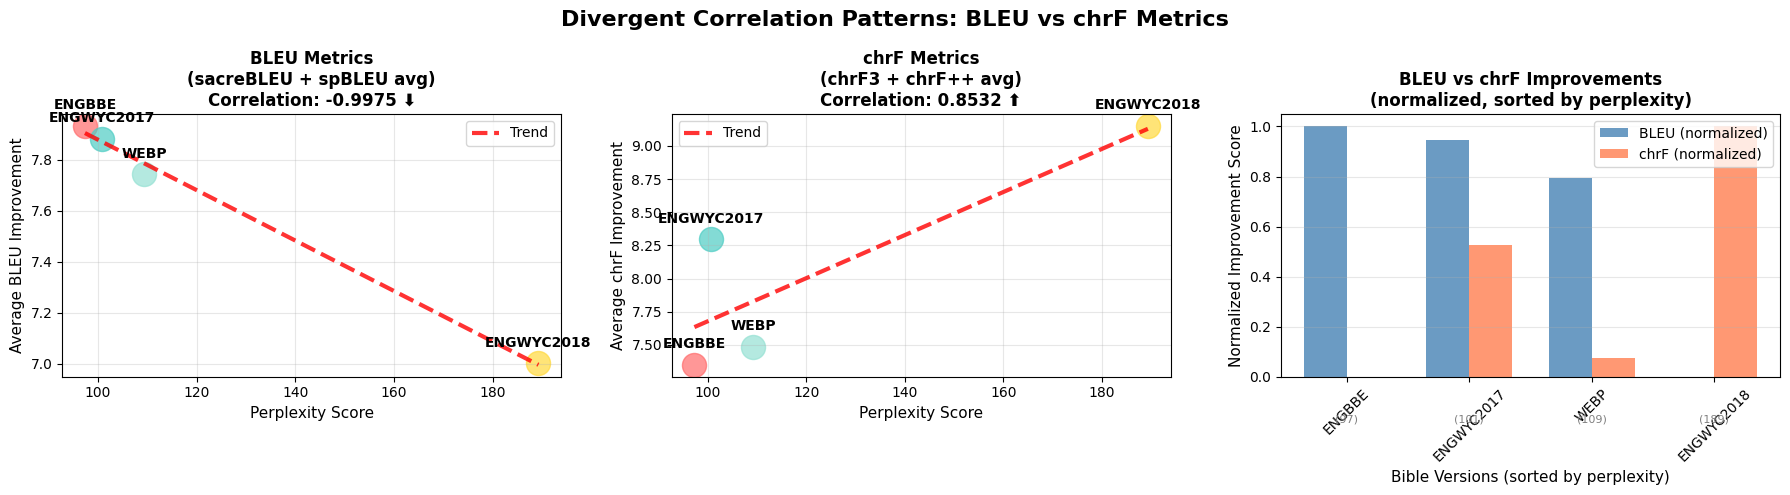

✅ Divergence visualization created!

📊 KEY OBSERVATION:
------------------------------------------------------------
The third chart shows the opposite trends clearly:
• As perplexity increases (left to right):
  - BLEU improvements DECREASE (blue bars get shorter)
  - chrF improvements INCREASE (orange bars get taller)

This confirms your observation of divergent correlation patterns!



In [9]:
# VISUALIZATION: Contrasting BLEU vs chrF correlations
print("\n" + "=" * 80)
print("STEP 9: VISUALIZING THE BLEU vs chrF DIVERGENCE")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Divergent Correlation Patterns: BLEU vs chrF Metrics', fontsize=16, fontweight='bold')

colors_map = {'engBBE': '#FF6B6B', 'engwyc2017': '#4ECDC4', 'engwyc2018': '#FFD93D', 'webp': '#95E1D3'}

# 1. Combined BLEU metrics vs Perplexity
ax1 = axes[0]
bleu_avg = correlation_df[['sacrebleu', 'spbleu']].mean(axis=1)

for _, row in correlation_df.iterrows():
    avg_bleu = (row['sacrebleu'] + row['spbleu']) / 2
    ax1.scatter(row['perplexity_score'], avg_bleu, 
                s=300, alpha=0.7, c=colors_map.get(row['variant'], 'gray'))
    ax1.annotate(row['variant'].upper(), 
                (row['perplexity_score'], avg_bleu),
                textcoords="offset points", xytext=(0,12), ha='center', fontsize=10, fontweight='bold')

# Trendline
x_line = np.linspace(correlation_df['perplexity_score'].min(), correlation_df['perplexity_score'].max(), 100)
z = np.polyfit(correlation_df['perplexity_score'], bleu_avg, 1)
p = np.poly1d(z)
ax1.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=3, label='Trend')

corr = correlation_df['perplexity_score'].corr(bleu_avg)
ax1.set_title(f'BLEU Metrics\n(sacreBLEU + spBLEU avg)\nCorrelation: {corr:.4f} ⬇️', fontweight='bold', fontsize=12)
ax1.set_xlabel('Perplexity Score', fontsize=11)
ax1.set_ylabel('Average BLEU Improvement', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Combined chrF metrics vs Perplexity
ax2 = axes[1]
chrf_avg = correlation_df[['chrf3', 'chrf++']].mean(axis=1)

for _, row in correlation_df.iterrows():
    avg_chrf = (row['chrf3'] + row['chrf++']) / 2
    ax2.scatter(row['perplexity_score'], avg_chrf, 
                s=300, alpha=0.7, c=colors_map.get(row['variant'], 'gray'))
    ax2.annotate(row['variant'].upper(), 
                (row['perplexity_score'], avg_chrf),
                textcoords="offset points", xytext=(0,12), ha='center', fontsize=10, fontweight='bold')

# Trendline
z = np.polyfit(correlation_df['perplexity_score'], chrf_avg, 1)
p = np.poly1d(z)
ax2.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=3, label='Trend')

corr = correlation_df['perplexity_score'].corr(chrf_avg)
ax2.set_title(f'chrF Metrics\n(chrF3 + chrF++ avg)\nCorrelation: {corr:.4f} ⬆️', fontweight='bold', fontsize=12)
ax2.set_xlabel('Perplexity Score', fontsize=11)
ax2.set_ylabel('Average chrF Improvement', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Side-by-side comparison with normalized values
ax3 = axes[2]

# Normalize both metrics to 0-1 scale for comparison
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

normalized_data = correlation_df.copy()
normalized_data['bleu_norm'] = scaler.fit_transform(bleu_avg.values.reshape(-1, 1))
normalized_data['chrf_norm'] = scaler.fit_transform(chrf_avg.values.reshape(-1, 1))

# Sort by perplexity for clearer visualization
normalized_data = normalized_data.sort_values('perplexity_score')

x_pos = np.arange(len(normalized_data))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, normalized_data['bleu_norm'], width, 
                label='BLEU (normalized)', color='steelblue', alpha=0.8)
bars2 = ax3.bar(x_pos + width/2, normalized_data['chrf_norm'], width,
                label='chrF (normalized)', color='coral', alpha=0.8)

ax3.set_xlabel('Bible Versions (sorted by perplexity)', fontsize=11)
ax3.set_ylabel('Normalized Improvement Score', fontsize=11)
ax3.set_title('BLEU vs chrF Improvements\n(normalized, sorted by perplexity)', fontweight='bold', fontsize=12)
ax3.set_xticks(x_pos)
ax3.set_xticklabels([v.upper() for v in normalized_data['variant']], rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Add perplexity values as secondary labels
for i, (idx, row) in enumerate(normalized_data.iterrows()):
    ax3.text(i, -0.15, f"({row['perplexity_score']:.0f})", 
             ha='center', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print("✅ Divergence visualization created!")
print("\n📊 KEY OBSERVATION:")
print("-" * 60)
print("The third chart shows the opposite trends clearly:")
print("• As perplexity increases (left to right):")
print("  - BLEU improvements DECREASE (blue bars get shorter)")
print("  - chrF improvements INCREASE (orange bars get taller)")
print()
print("This confirms your observation of divergent correlation patterns!")

print("\n" + "=" * 80)


In [10]:
# CORRELATION ANALYSIS: Perplexity vs FINAL Post-Edited Scores
print("\n" + "=" * 80)
print("STEP 10: PERPLEXITY vs FINAL POST-EDITED PERFORMANCE")
print("=" * 80)

print("\nPrevious analysis looked at IMPROVEMENTS.")
print("Now let's analyze the FINAL POST-EDITED SCORES.\n")

# Merge post-edited scores with perplexity
pe_correlation_df = best_pe_df.merge(perplexity_filtered_df, on='variant', how='inner')

print("📋 FINAL POST-EDITED SCORES BY VARIANT:")
print("-" * 60)
display_pe_df = pe_correlation_df[['variant', 'training_config', 'perplexity_score', 'sacrebleu', 'spbleu', 'chrf3', 'chrf++']].copy()
display_pe_df = display_pe_df.sort_values('perplexity_score')
display_pe_df['variant'] = display_pe_df['variant'].str.upper()
print(display_pe_df.to_string(index=False))

# Calculate correlations for final scores
print("\n📈 CORRELATION ANALYSIS (Perplexity vs Final Scores):")
print("-" * 60)
print("Correlation between perplexity score and FINAL post-edited metrics:\n")

bleu_metrics = ['sacrebleu', 'spbleu']
chrf_metrics = ['chrf3', 'chrf++']

print("BLEU-based metrics (final scores):")
for metric in bleu_metrics:
    corr = pe_correlation_df['perplexity_score'].corr(pe_correlation_df[metric])
    print(f"  {metric:12}: {corr:7.4f}")
    if abs(corr) < 0.3:
        strength = "weak"
    elif abs(corr) < 0.7:
        strength = "moderate"
    else:
        strength = "strong"
    direction = "positive" if corr > 0 else "negative"
    print(f"             ({strength} {direction} correlation)")
    if corr > 0:
        print(f"             → Higher perplexity → Higher final score")
    else:
        print(f"             → Higher perplexity → Lower final score")
    print()

print("\nchrF-based metrics (final scores):")
for metric in chrf_metrics:
    corr = pe_correlation_df['perplexity_score'].corr(pe_correlation_df[metric])
    print(f"  {metric:12}: {corr:7.4f}")
    if abs(corr) < 0.3:
        strength = "weak"
    elif abs(corr) < 0.7:
        strength = "moderate"
    else:
        strength = "strong"
    direction = "positive" if corr > 0 else "negative"
    print(f"             ({strength} {direction} correlation)")
    if corr > 0:
        print(f"             → Higher perplexity → Higher final score")
    else:
        print(f"             → Higher perplexity → Lower final score")
    print()

# Calculate average final score
pe_correlation_df['avg_final_score'] = pe_correlation_df[metrics_to_analyze].mean(axis=1)
corr_avg = pe_correlation_df['perplexity_score'].corr(pe_correlation_df['avg_final_score'])

print(f"  {'Avg Final':10}: {corr_avg:7.4f}")
if abs(corr_avg) < 0.3:
    strength = "weak"
elif abs(corr_avg) < 0.7:
    strength = "moderate"
else:
    strength = "strong"
direction = "positive" if corr_avg > 0 else "negative"
print(f"             ({strength} {direction} correlation)")
print(f"             → Average across all metrics")

print("\n💡 INTERPRETATION:")
print("-" * 60)
print("This analysis shows whether perplexity predicts FINAL performance quality,")
print("rather than just the magnitude of improvement from post-editing.")

print("\n" + "=" * 80)



STEP 10: PERPLEXITY vs FINAL POST-EDITED PERFORMANCE

Previous analysis looked at IMPROVEMENTS.
Now let's analyze the FINAL POST-EDITED SCORES.

📋 FINAL POST-EDITED SCORES BY VARIANT:
------------------------------------------------------------
   variant  training_config  perplexity_score  sacrebleu  spbleu   chrf3  chrf++
    ENGBBE parallel_full+nt           97.3408     9.7977 18.2573 36.4660 34.3354
ENGWYC2017 parallel_full+nt          100.7690     9.5432 17.8555 36.9829 34.6674
      WEBP parallel_full+nt          109.3180     9.8137 18.7229 37.2781 34.9983
ENGWYC2018 parallel_full+nt          189.3110     8.1653 15.4383 37.9372 34.7872

📈 CORRELATION ANALYSIS (Perplexity vs Final Scores):
------------------------------------------------------------
Correlation between perplexity score and FINAL post-edited metrics:

BLEU-based metrics (final scores):
  sacrebleu   : -0.9757
             (strong negative correlation)
             → Higher perplexity → Lower final score

  spbleu 


STEP 11: VISUALIZING PERPLEXITY vs FINAL SCORES


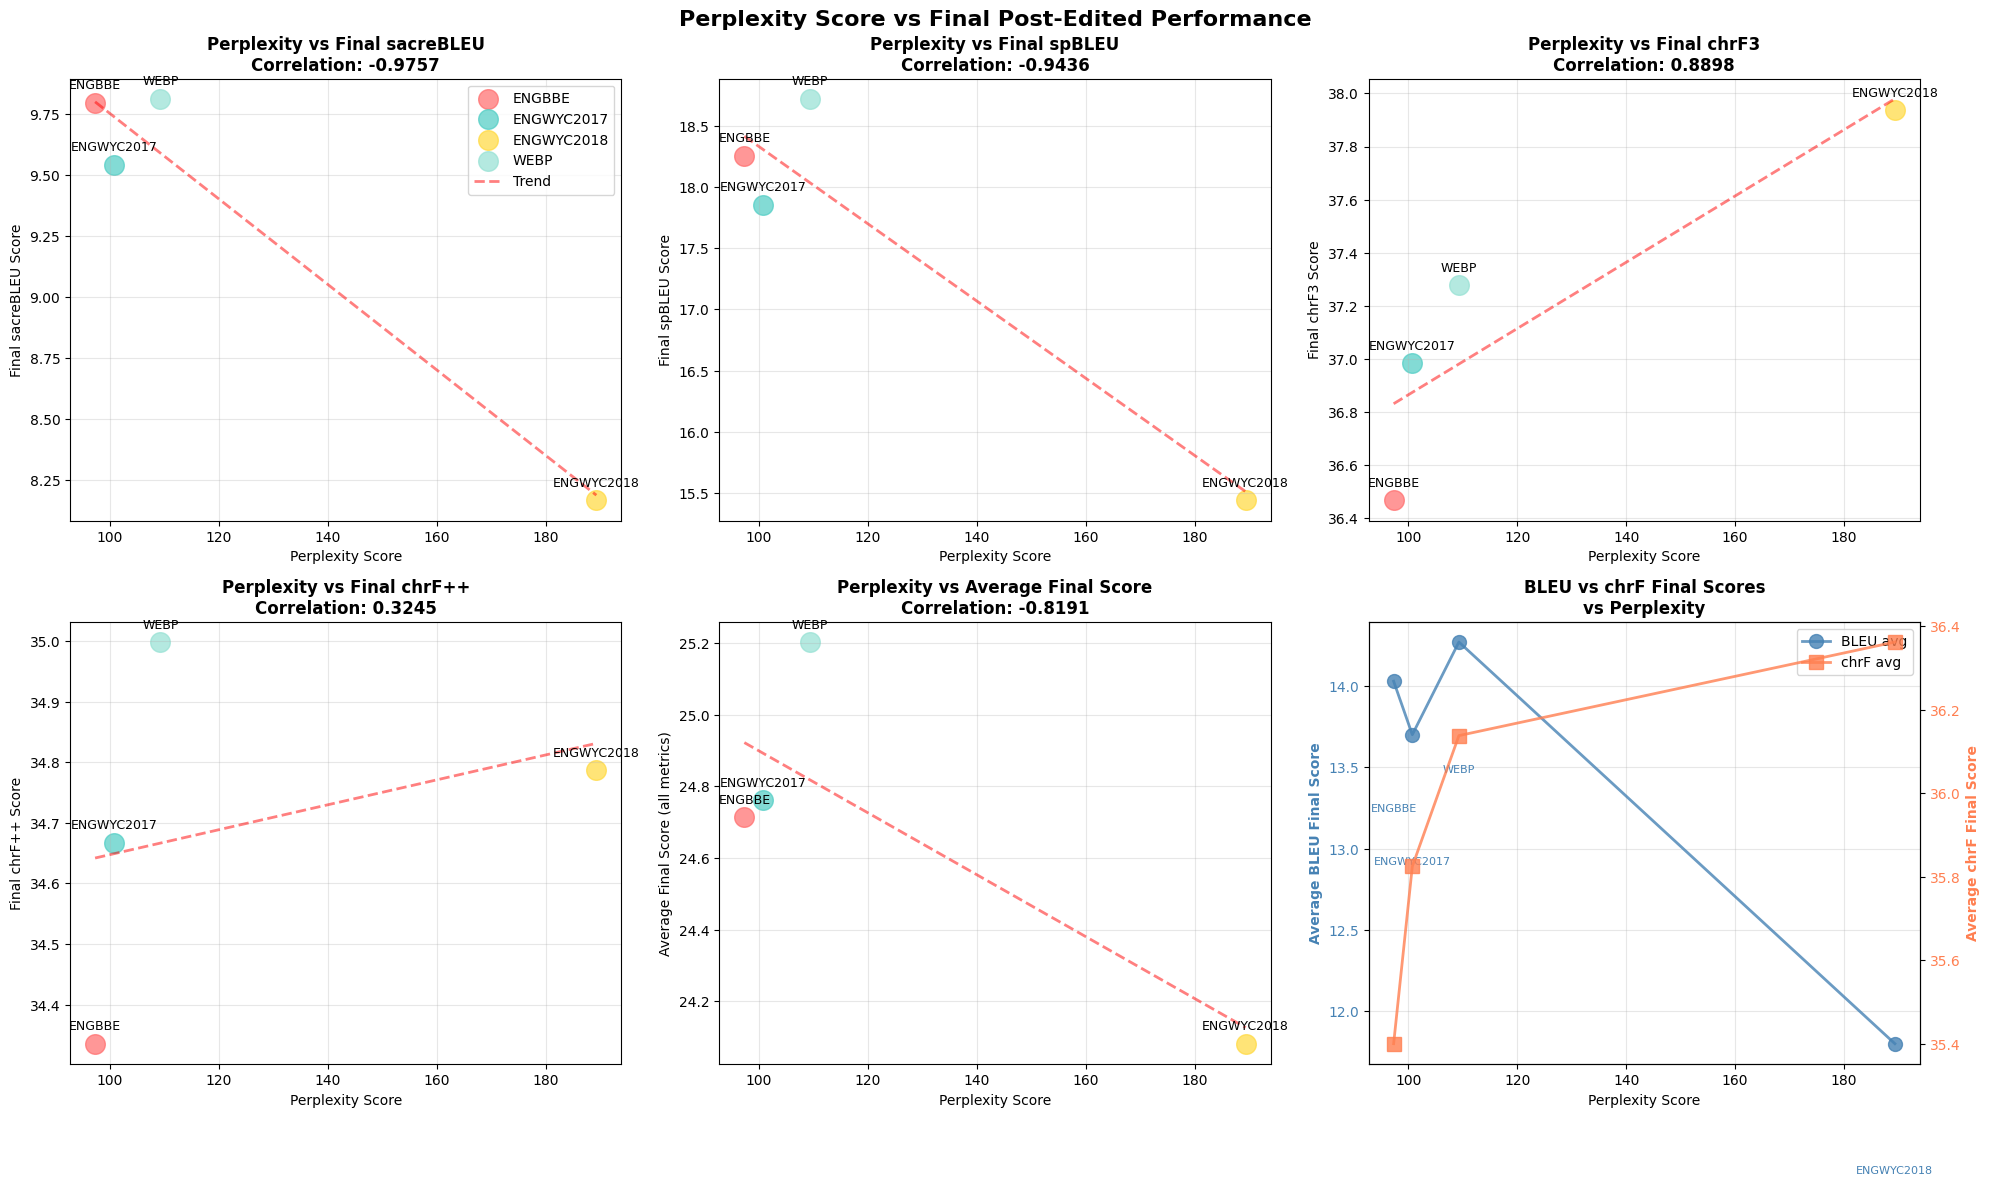

✅ Final score correlation visualizations created!

📊 Key Insights:
   • These plots show if perplexity predicts FINAL performance quality
   • Compare with improvement correlations to see full picture
   • The dual-axis plot (bottom-right) shows BLEU and chrF trends together



In [11]:
# VISUALIZATION: Perplexity vs Final Post-Edited Scores
print("\n" + "=" * 80)
print("STEP 11: VISUALIZING PERPLEXITY vs FINAL SCORES")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Perplexity Score vs Final Post-Edited Performance', fontsize=16, fontweight='bold')

colors_map = {'engBBE': '#FF6B6B', 'engwyc2017': '#4ECDC4', 'engwyc2018': '#FFD93D', 'webp': '#95E1D3'}
x_line = np.linspace(pe_correlation_df['perplexity_score'].min(), pe_correlation_df['perplexity_score'].max(), 100)

# 1. Scatter plot: Perplexity vs sacreBLEU final score
ax1 = axes[0, 0]
for _, row in pe_correlation_df.iterrows():
    ax1.scatter(row['perplexity_score'], row['sacrebleu'], 
                s=200, alpha=0.7, c=colors_map.get(row['variant'], 'gray'),
                label=row['variant'].upper())
    ax1.annotate(row['variant'].upper(), 
                (row['perplexity_score'], row['sacrebleu']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

z = np.polyfit(pe_correlation_df['perplexity_score'], pe_correlation_df['sacrebleu'], 1)
p = np.poly1d(z)
ax1.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2, label='Trend')

corr1 = pe_correlation_df['perplexity_score'].corr(pe_correlation_df['sacrebleu'])
ax1.set_title(f'Perplexity vs Final sacreBLEU\nCorrelation: {corr1:.4f}', fontweight='bold')
ax1.set_xlabel('Perplexity Score')
ax1.set_ylabel('Final sacreBLEU Score')
ax1.grid(True, alpha=0.3)
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='best')

# 2. Scatter plot: Perplexity vs spBLEU final score
ax2 = axes[0, 1]
for _, row in pe_correlation_df.iterrows():
    ax2.scatter(row['perplexity_score'], row['spbleu'], 
                s=200, alpha=0.7, c=colors_map.get(row['variant'], 'gray'))
    ax2.annotate(row['variant'].upper(), 
                (row['perplexity_score'], row['spbleu']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

z = np.polyfit(pe_correlation_df['perplexity_score'], pe_correlation_df['spbleu'], 1)
p = np.poly1d(z)
ax2.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)

corr2 = pe_correlation_df['perplexity_score'].corr(pe_correlation_df['spbleu'])
ax2.set_title(f'Perplexity vs Final spBLEU\nCorrelation: {corr2:.4f}', fontweight='bold')
ax2.set_xlabel('Perplexity Score')
ax2.set_ylabel('Final spBLEU Score')
ax2.grid(True, alpha=0.3)

# 3. Scatter plot: Perplexity vs chrF3 final score
ax3 = axes[0, 2]
for _, row in pe_correlation_df.iterrows():
    ax3.scatter(row['perplexity_score'], row['chrf3'], 
                s=200, alpha=0.7, c=colors_map.get(row['variant'], 'gray'))
    ax3.annotate(row['variant'].upper(), 
                (row['perplexity_score'], row['chrf3']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

z = np.polyfit(pe_correlation_df['perplexity_score'], pe_correlation_df['chrf3'], 1)
p = np.poly1d(z)
ax3.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)

corr3 = pe_correlation_df['perplexity_score'].corr(pe_correlation_df['chrf3'])
ax3.set_title(f'Perplexity vs Final chrF3\nCorrelation: {corr3:.4f}', fontweight='bold')
ax3.set_xlabel('Perplexity Score')
ax3.set_ylabel('Final chrF3 Score')
ax3.grid(True, alpha=0.3)

# 4. Scatter plot: Perplexity vs chrF++ final score
ax4 = axes[1, 0]
for _, row in pe_correlation_df.iterrows():
    ax4.scatter(row['perplexity_score'], row['chrf++'], 
                s=200, alpha=0.7, c=colors_map.get(row['variant'], 'gray'))
    ax4.annotate(row['variant'].upper(), 
                (row['perplexity_score'], row['chrf++']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

z = np.polyfit(pe_correlation_df['perplexity_score'], pe_correlation_df['chrf++'], 1)
p = np.poly1d(z)
ax4.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)

corr4 = pe_correlation_df['perplexity_score'].corr(pe_correlation_df['chrf++'])
ax4.set_title(f'Perplexity vs Final chrF++\nCorrelation: {corr4:.4f}', fontweight='bold')
ax4.set_xlabel('Perplexity Score')
ax4.set_ylabel('Final chrF++ Score')
ax4.grid(True, alpha=0.3)

# 5. Scatter plot: Perplexity vs Average final score
ax5 = axes[1, 1]
for _, row in pe_correlation_df.iterrows():
    ax5.scatter(row['perplexity_score'], row['avg_final_score'], 
                s=200, alpha=0.7, c=colors_map.get(row['variant'], 'gray'))
    ax5.annotate(row['variant'].upper(), 
                (row['perplexity_score'], row['avg_final_score']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

z = np.polyfit(pe_correlation_df['perplexity_score'], pe_correlation_df['avg_final_score'], 1)
p = np.poly1d(z)
ax5.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)

corr5 = pe_correlation_df['perplexity_score'].corr(pe_correlation_df['avg_final_score'])
ax5.set_title(f'Perplexity vs Average Final Score\nCorrelation: {corr5:.4f}', fontweight='bold')
ax5.set_xlabel('Perplexity Score')
ax5.set_ylabel('Average Final Score (all metrics)')
ax5.grid(True, alpha=0.3)

# 6. Combined comparison: BLEU vs chrF final scores
ax6 = axes[1, 2]
bleu_avg_final = pe_correlation_df[['sacrebleu', 'spbleu']].mean(axis=1)
chrf_avg_final = pe_correlation_df[['chrf3', 'chrf++']].mean(axis=1)

pe_correlation_df_sorted = pe_correlation_df.sort_values('perplexity_score')
bleu_avg_final_sorted = pe_correlation_df_sorted[['sacrebleu', 'spbleu']].mean(axis=1)
chrf_avg_final_sorted = pe_correlation_df_sorted[['chrf3', 'chrf++']].mean(axis=1)

ax6_twin = ax6.twinx()

line1 = ax6.plot(pe_correlation_df_sorted['perplexity_score'], bleu_avg_final_sorted, 
                 'o-', color='steelblue', linewidth=2, markersize=10, alpha=0.8, label='BLEU avg')
line2 = ax6_twin.plot(pe_correlation_df_sorted['perplexity_score'], chrf_avg_final_sorted, 
                      's-', color='coral', linewidth=2, markersize=10, alpha=0.8, label='chrF avg')

ax6.set_xlabel('Perplexity Score')
ax6.set_ylabel('Average BLEU Final Score', color='steelblue', fontweight='bold')
ax6_twin.set_ylabel('Average chrF Final Score', color='coral', fontweight='bold')
ax6.tick_params(axis='y', labelcolor='steelblue')
ax6_twin.tick_params(axis='y', labelcolor='coral')

# Add variant labels
for _, row in pe_correlation_df.iterrows():
    bleu_avg = (row['sacrebleu'] + row['spbleu']) / 2
    ax6.text(row['perplexity_score'], bleu_avg - 0.8, row['variant'].upper(), 
            ha='center', fontsize=8, color='steelblue')

ax6.grid(True, alpha=0.3)
ax6.set_title('BLEU vs chrF Final Scores\nvs Perplexity', fontweight='bold')

# Combine legends
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6_twin.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

print("✅ Final score correlation visualizations created!")
print("\n📊 Key Insights:")
print("   • These plots show if perplexity predicts FINAL performance quality")
print("   • Compare with improvement correlations to see full picture")
print("   • The dual-axis plot (bottom-right) shows BLEU and chrF trends together")

print("\n" + "=" * 80)
